In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report,recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
titanic_train = pd.read_csv("Titanic_train.csv")
titanic_test = pd.read_csv("Titanic_test.csv")

print("Training Data Shape:", titanic_train.shape)
print("Test Data Shape:", titanic_test.shape)

Training Data Shape: (891, 12)
Test Data Shape: (418, 11)


In [3]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
titanic_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
titanic_train.duplicated().sum()

np.int64(0)

In [8]:
# Dropping unnecessary columns
titanic_train = titanic_train.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

- The columns PassengerId, Name, and Ticket were dropped because they do not contribute meaningful information for predicting survival.
- The Cabin column was removed due to a high number of missing values, which makes it unreliable for modeling.

In [9]:
# Filling missing values
titanic_train["Embarked"].fillna(titanic_train["Embarked"].mode()[0], inplace=True)
titanic_train["Age"].fillna(titanic_train["Age"].median(), inplace=True)

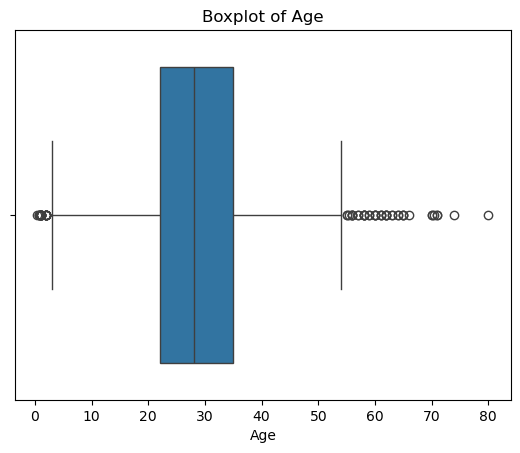

In [10]:
sns.boxplot(x=titanic_train["Age"])
plt.title("Boxplot of Age")
plt.show()

Although some extreme values exist in Age, they represent real passengers and were retained for modeling.

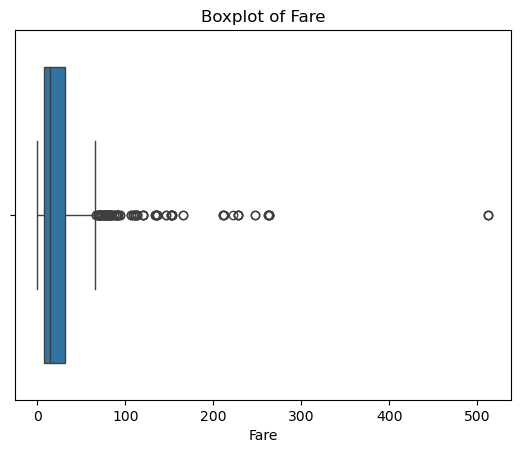

In [11]:
sns.boxplot(x=titanic_train["Fare"])
plt.title("Boxplot of Fare")
plt.show()

Although Fare shows skewness and some extreme values, they represent valid ticket prices and were retained.

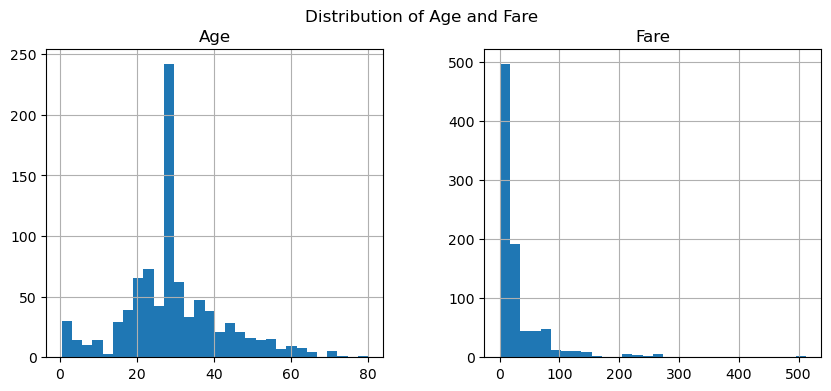

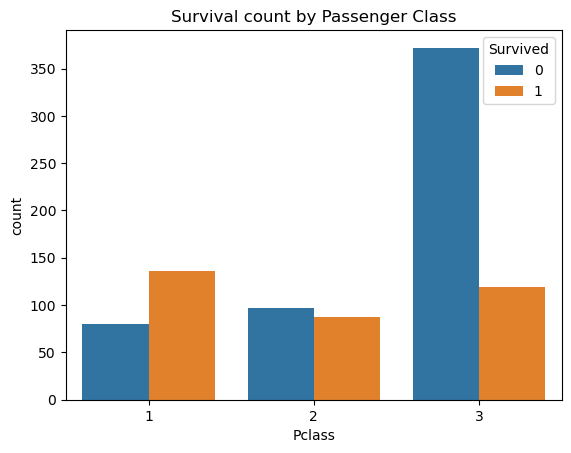

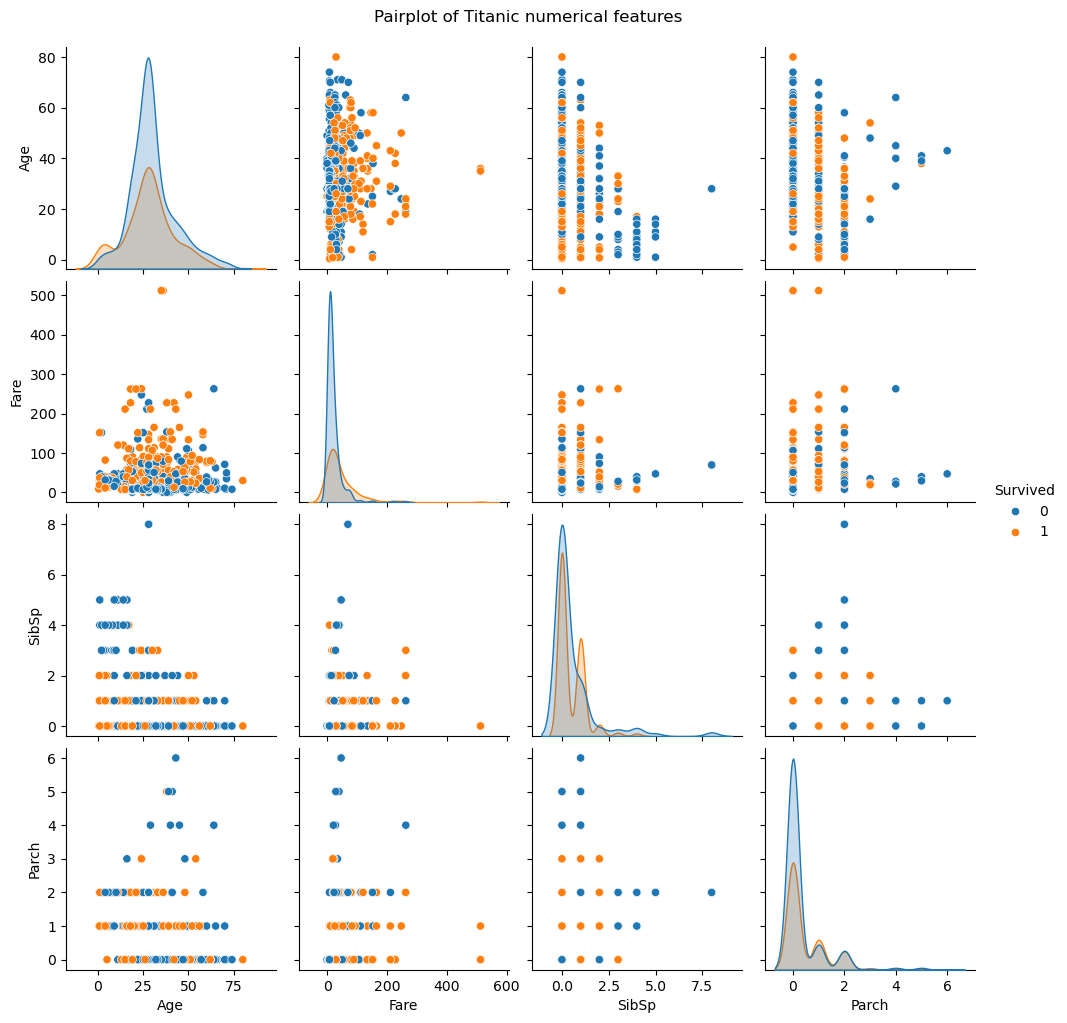

In [12]:
# Visualizations
# Histogram for Age and Fare
titanic_train[['Age', 'Fare']].hist(bins=30, figsize=(10,4))
plt.suptitle("Distribution of Age and Fare")
plt.show()

# Countplot for Survived vs Pclass
sns.countplot(data=titanic_train, x='Pclass', hue='Survived')
plt.title("Survival count by Passenger Class")
plt.show()

# Pairplot for selected numerical variables
sns.pairplot(titanic_train[['Survived', 'Age', 'Fare', 'SibSp', 'Parch']], hue='Survived')
plt.suptitle("Pairplot of Titanic numerical features", y=1.02)
plt.show()

In [13]:
# Initialize label_encoders for Sex
label_encoder_sex = LabelEncoder()
titanic_train["Sex"] = label_encoder_sex.fit_transform(titanic_train["Sex"])


In [14]:
# One-Hot Encoding for Embarked
titanic_train = pd.get_dummies(titanic_train, columns=["Embarked"], drop_first=True)

In [15]:
titanic_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


- The Embarked column was successfully one-hot encoded.
- The original column was replaced with binary columns (Embarked_Q and Embarked_S), with one category dropped to avoid multicollinearity.

In [16]:
# Drop unnecessary columns
titanic_test = titanic_test.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Encode Sex (using same encoder as training)
titanic_test["Sex"] = label_encoder_sex.transform(titanic_test["Sex"])

# Handle missing values
titanic_test["Age"].fillna(titanic_train["Age"].median(), inplace=True)
titanic_test["Fare"].fillna(titanic_train["Fare"].median(), inplace=True)
titanic_test["Embarked"].fillna(titanic_test["Embarked"].mode()[0], inplace=True)

# One-Hot Encoding for Embarked
titanic_test = pd.get_dummies(titanic_test, columns=["Embarked"], drop_first=True)

# Align test columns with training features
titanic_test = titanic_test.reindex(columns=titanic_train.drop("Survived", axis=1).columns, fill_value=0)

In [17]:
# Logistic Regression Model
X = titanic_train.drop("Survived", axis=1)
y = titanic_train["Survived"]

In [18]:
# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [19]:
# Fit model on training data
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
# Predictions and evaluation
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(classification_report(y_test, y_pred))

Accuracy: 75.98%
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.64      0.67        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179



In [21]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[92 18]
 [25 44]]


In [22]:
y_prob = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

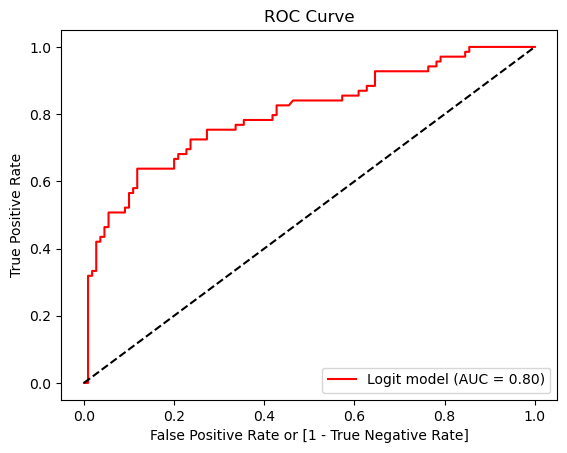

ROC-AUC Score: 0.8013833992094862


In [24]:
plt.plot(fpr, tpr, color='red', label='Logit model (AUC = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC Curve')
plt.show()
print("ROC-AUC Score:", auc)

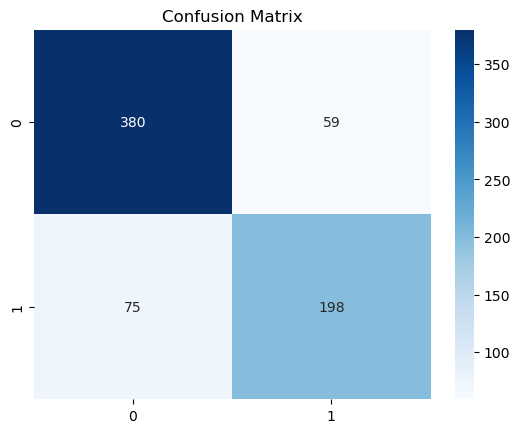

In [25]:
# Confusion Matrix
y_pred_train = model.predict(x_train)
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [28]:
# Interpretation using sklearn
coeff_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Logistic Regression Coefficients:")
print(coeff_df)

print("\nIntercept:", model.intercept_[0])

Logistic Regression Coefficients:
      Feature  Coefficient
4       Parch     0.030755
5        Fare     0.001162
2         Age    -0.044042
6  Embarked_Q    -0.183681
3       SibSp    -0.401562
7  Embarked_S    -0.497259
0      Pclass    -1.041142
1         Sex    -2.833764

Intercept: 5.377133157195398


**Interpretation**

- Positive values mean higher chance of survival, and negative values mean lower chance of survival.
- The model shows that being male reduces survival chances. Passengers in lower classes were also less likely to survive.
- Older passengers had slightly lower survival chances. People who paid higher fares had a slightly better chance of surviving.
- Gender and passenger class were the most important factors.

In [33]:
import pickle
pickle.dump(model, open("titanic_model.pkl", "wb"))

### Conclusion:

- The logistic regression model was able to predict passenger survival with good accuracy.
- The results show that being female and traveling in higher classes greatly increased survival chances, while age and fare had smaller effects.
- The model performed well with an accuracy of 75.98% and an ROC-AUC of 0.801, proving it can effectively separate survivors from non-survivors.
- Overall, the analysis confirms that gender and class were the most significant factors influencing survival on the Titanic.


### INterview Questions
#### 1. What is the difference between precision and recall?

Precision and Recall are evaluation metrics used in Logistic Regression and other classification models.
- Precision: It measures how many of the predicted positive cases are actually correct.
- Precision = True Positives / (True Positives + False Positives)
- Recall: It measures how many of the actual positive cases the model correctly identified.
- Recall = True Positives / (True Positives + False Negatives)


#### 2. What is cross-validation, and why is it important in binary classification?

- Cross-validation is a technique used to evaluate how well a model will perform on new, unseen data. In this method, the dataset is divided into several smaller parts (called folds).
-  The model is trained on some parts and tested on the remaining part, and this process is repeated multiple times.

**Why it is important in binary classification:**

- It helps check whether the model is generalizing well to new data.
- It reduces the risk of overfitting.
- It gives a more reliable estimate of model performance than using a single train-test split.